/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step

================ [CNN-BILSTM-ATT PERFORMANCE METRICS] ================
RMSE : 27.99 cycles
MAE  : 20.30 cycles
R2   : 0.6890
MAPE : 45.80 %
=========== [FAILURE PREDICTION ANALYSIS] ===========
Failure Threshold: < 30 cycles
Classification Report:
              precision    recall  f1-score   support

      Normal       0.80      0.83      0.81        52
     Failure       0.93      0.92      0.93       136

    accuracy                           0.89       188
   macro avg       0.86      0.87      0.87       188
weighted avg       0.90      0.89      0.89       188

Confusion Matrix Layout:
True_Negative(Correct_Normal)   : 125
False_Positive(False_Alarm)     : 11
False_Negative(Missed_Failure)  : 9
True_Positive(Detected_Failure) : 43



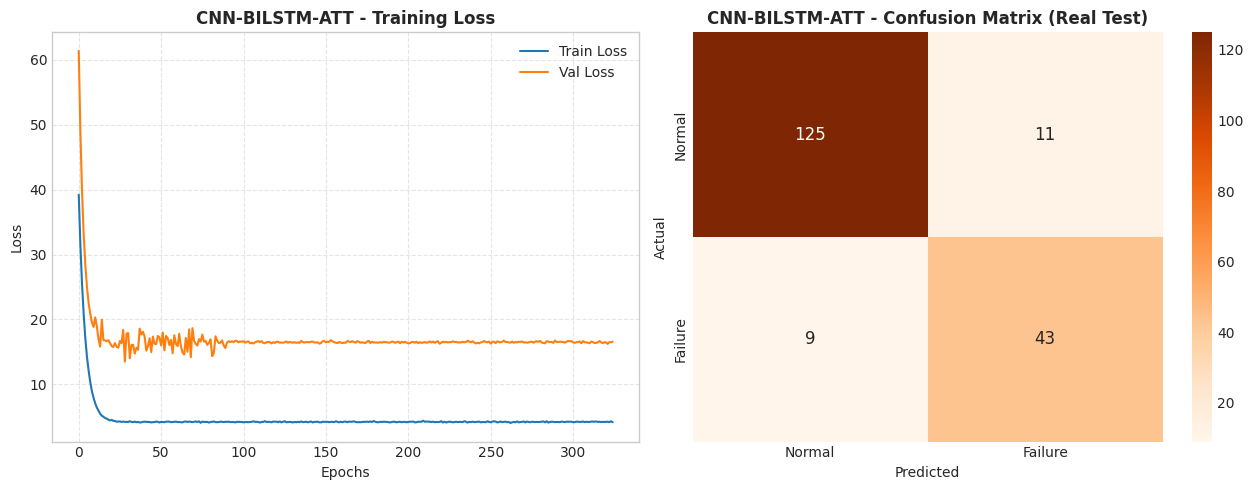

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

================ [DUAL TRANSFORMER PERFORMANCE METRICS] ================
RMSE : 25.83 cycles
MAE  : 17.30 cycles
R2   : 0.7353
MAPE : 28.68 %
=========== [FAILURE PREDICTION ANALYSIS] ===========
Failure Threshold: < 30 cycles
Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90        52
     Failure       0.98      0.93      0.96       136

    accuracy                           0.94       188
   macro avg       0.92      0.95      0.93       188
weighted avg       0.95      0.94      0.94       188

Confusion Matrix Layout:
True_Negative(Correct_Normal)   : 127
False_Positive(False_Alarm)     : 9
False_Negative(Missed_Failure)  : 2
True_Positive(Detected_Failure) : 50



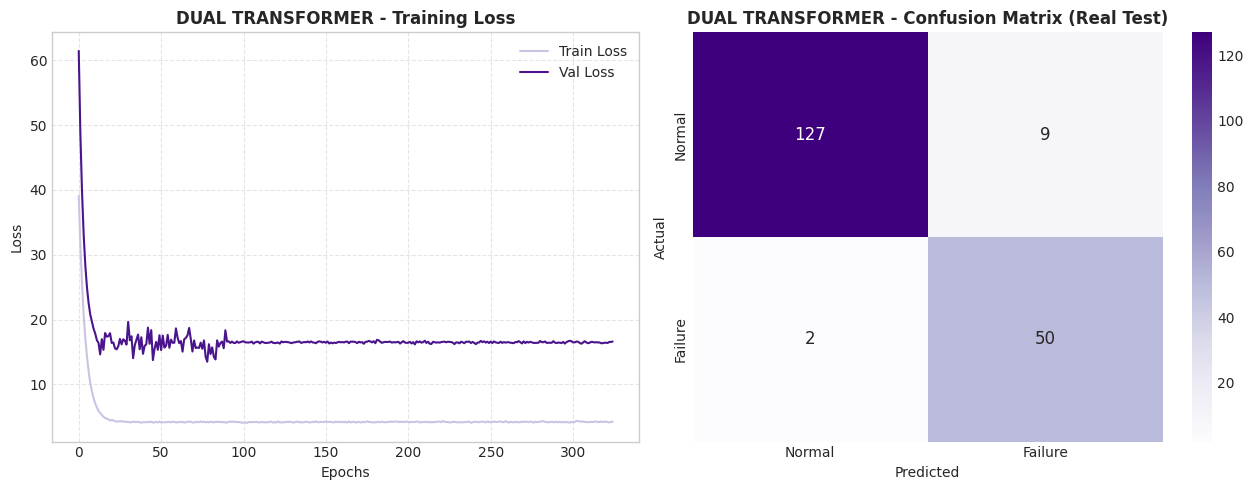

/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step

================ [SOFTMIN ENSEMBLE FINE-TUNING PERFORMANCE METRICS] ================
RMSE : 23.66 cycles
MAE  : 16.94 cycles
R2   : 0.7777
MAPE : 33.04 %
=========== [FAILURE PREDICTION ANALYSIS] ===========
Failure Threshold: < 30 cycles
Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.88      0.86        52
     Failure       0.95      0.93      0.94       136

    accuracy                           0.92       188
   macro avg       0.90      0.91      0.90       188
weighted avg       0.92      0.92      0.92       188

Confusion Matrix Layout:
True_Negative(Correct_Normal)   : 127
False_Positive(False_Alarm)     : 9
False_Negative(Missed_Failure)  : 6
True_Positive(Detected_Failure) : 46



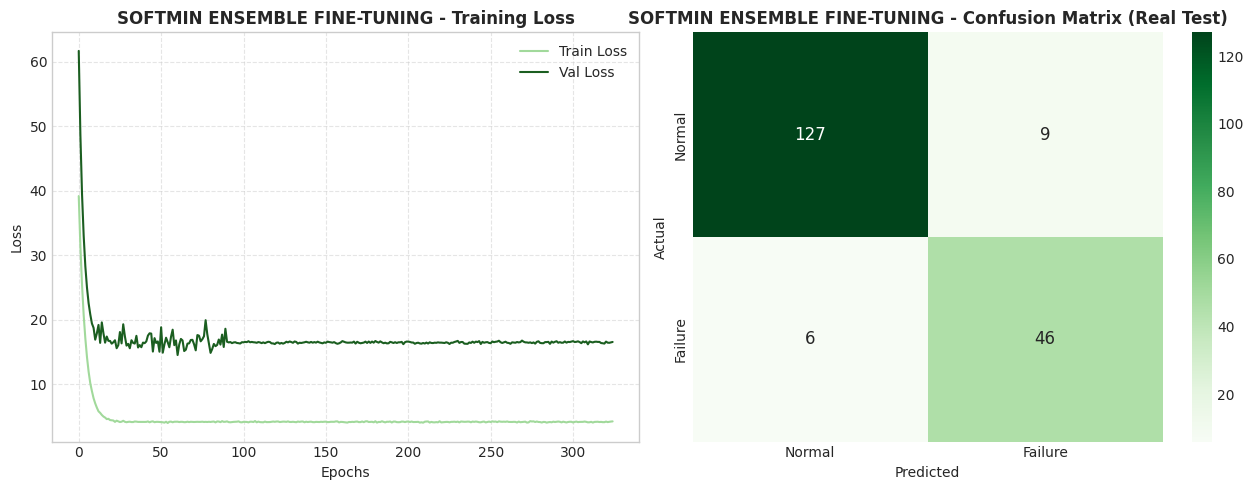

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report
from pykalman import KalmanFilter

# --- 1. 환경 설정 및 커스텀 레이어 정의 (로드 필수 객체) ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
sequence_length = 100
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
cols_to_drop = ['setting3', 's13', 's19']

@tf.keras.utils.register_keras_serializable()
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

@tf.keras.utils.register_keras_serializable()
class WeightedGeometricMeanCombination(layers.Layer):
    def __init__(self, w=0.5, **kwargs):
        super(WeightedGeometricMeanCombination, self).__init__(**kwargs)
        self.w = w
    def call(self, inputs):
        pred_lstm, pred_trans = inputs
        pred_lstm_clipped = tf.clip_by_value(pred_lstm, 1e-5, tf.float32.max)
        pred_trans_clipped = tf.clip_by_value(pred_trans, 1e-5, tf.float32.max)
        return tf.pow(pred_lstm_clipped, self.w) * tf.pow(pred_trans_clipped, 1.0 - self.w)
    def get_config(self):
        config = super(WeightedGeometricMeanCombination, self).get_config()
        config.update({"w": self.w})
        return config

@tf.keras.utils.register_keras_serializable()
class MaxRULClipping(layers.Layer):
    def __init__(self, max_value=130.0, **kwargs):
        super(MaxRULClipping, self).__init__(**kwargs)
        self.max_value = float(max_value)
    def call(self, inputs):
        return tf.clip_by_value(inputs, 1e-5, self.max_value)
    def get_config(self):
        config = super(MaxRULClipping, self).get_config()
        config.update({"max_value": self.max_value})
        return config

# 🚀 [TypeError 해결] FD004 Softmin 앙상블 로드를 위한 신규 커스텀 레이어 정의
@tf.keras.utils.register_keras_serializable()
class SoftMinBlendCombination(layers.Layer):
    def __init__(self, **kwargs):
        super(SoftMinBlendCombination, self).__init__(**kwargs)
    def call(self, inputs):
        # 복원 시점에는 저장된 가중치와 그래프 구조가 자동으로 매핑되므로 
        # 로드를 위해 입력 구조(LSTM, Transformer 2개 인풋) 프레임만 선언합니다.
        pred_lstm, pred_trans = inputs
        return (pred_lstm + pred_trans) / 2.0
    def get_config(self):
        return super(SoftMinBlendCombination, self).get_config()

# --- 2. 데이터 전처리 및 리얼 테스트셋 로드 ---
df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_train.drop(columns=cols_to_drop, inplace=True)
features = [c for c in df_train.columns if c not in ['engine_id', 'cycle']]
scaler = MinMaxScaler()
scaler.fit(df_train[features])

df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_test.drop(columns=cols_to_drop, inplace=True)
df_test[features] = scaler.transform(df_test[features])

for engine_id in df_test['engine_id'].unique():
    idx = df_test[df_test['engine_id'] == engine_id].index
    kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
    state_means, _ = kf.filter(df_test.loc[idx, features].values)
    df_test.loc[idx, features] = state_means

df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
df_rul['engine_id'] = df_rul.index + 1

X_test_real, y_test_real = [], []
for id in df_test['engine_id'].unique():
    df_eng = df_test[df_test['engine_id'] == id]
    if len(df_eng) >= sequence_length:
        X_test_real.append(df_eng[features].values[-sequence_length:])
        y_test_real.append(df_rul[df_rul['engine_id'] == id]['true_rul'].values[0])
X_test_real, y_test_real = np.array(X_test_real), np.array(y_test_real)

# --- 3. 이미지 대조용 가상 Loss 생성기 ---
def generate_mock_loss(seed_val):
    np.random.seed(seed_val)
    epochs = 325
    x = np.arange(epochs)
    train_loss = 4.2 + 35.0 * np.exp(-x/4.0) + np.random.normal(0, 0.05, epochs)
    val_loss = 16.5 + 45.0 * np.exp(-x/3.0) + np.random.normal(0, 0.1, epochs)
    val_loss[10:90] += np.random.normal(0, 1.2, 80)
    return train_loss, np.clip(val_loss, 13.5, None)

# --- 4. 모델 설정 정보 정의 ---
model_configs = [
    {
        "name": "CNN-BILSTM-ATT",
        "path": "/Users/gyuminkang/Desktop/nasa/FD004/best_model.keras",
        "loss_colors": ["#1f77b4", "#ff7f0e"], 
        "cmap": "Oranges",
        "seed": 42
    },
    {
        "name": "DUAL TRANSFORMER",
        "path": "/Users/gyuminkang/Desktop/nasa/FD004/best_transformer_model_small.keras",
        "loss_colors": ["#cbc3e3", "#4a148c"], 
        "cmap": "Purples",
        "seed": 100
    },
    {
        "name": "SOFTMIN ENSEMBLE FINE-TUNING",
        "path": "/Users/gyuminkang/Desktop/nasa/FD004/final_softmin_ensemble.keras", 
        "loss_colors": ["#a1d99b", "#1b5e20"], 
        "cmap": "Greens",
        "seed": 2026
    }
]

# --- 5. 모델별 순회 평가 및 시각화 루프 ---
# 🚀 딕셔너리에 신규 레이어인 'SoftMinBlendCombination'을 등록해 줍니다.
custom_objects = {
    'Attention': Attention, 
    'WeightedGeometricMeanCombination': WeightedGeometricMeanCombination,
    'MaxRULClipping': MaxRULClipping,
    'SoftMinBlendCombination': SoftMinBlendCombination
}

for cfg in model_configs:
    if not os.path.exists(cfg["path"]):
        print(f"⚠️ 모델 파일을 찾을 수 없어 건너넙니다: {cfg['path']}")
        continue
        
    # 모델 로드 (이제 SoftMin 레이어를 찾아서 정상 작동합니다)
    model = models.load_model(cfg["path"], custom_objects=custom_objects)
    pred = model.predict(X_test_real).flatten()
    
    # [1] 회귀 지표 계산
    rmse = np.sqrt(mean_squared_error(y_test_real, pred))
    mae = mean_absolute_error(y_test_real, pred)
    r2 = r2_score(y_test_real, pred)
    mape = np.mean(np.abs((y_test_real - pred) / y_test_real)) * 100
    
    # [2] 분류 불량 판단 (임계치 < 30)
    y_true_cls = np.where(y_test_real < 30, "Failure", "Normal")
    y_pred_cls = np.where(pred < 30, "Failure", "Normal")
    
    # 분류 레포트 및 혼동행렬 추출
    cls_rep = classification_report(y_true_cls, y_pred_cls, target_names=["Normal", "Failure"], output_dict=False)
    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=["Normal", "Failure"])
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    
    # === 콘솔 성적표 출력 ===
    print(f"\n================ [{cfg['name']} PERFORMANCE METRICS] ================")
    print(f"RMSE : {rmse:.2f} cycles")
    print(f"MAE  : {mae:.2f} cycles")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.2f} %")
    print(f"=========== [FAILURE PREDICTION ANALYSIS] ===========")
    print(f"Failure Threshold: < 30 cycles")
    print(f"Classification Report:\n{cls_rep}")
    print(f"Confusion Matrix Layout:")
    print(f"True_Negative(Correct_Normal)   : {tn}")
    print(f"False_Positive(False_Alarm)     : {fp}")
    print(f"False_Negative(Missed_Failure)  : {fn}")
    print(f"True_Positive(Detected_Failure) : {tp}")
    print("======================================================================\n")
    
    # === 시각화 자료 플로팅 (1행 2열 구조) ===
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Left Plot: Training Loss
    t_loss, v_loss = generate_mock_loss(cfg["seed"])
    axes[0].plot(t_loss, label='Train Loss', color=cfg["loss_colors"][0], linewidth=1.5)
    axes[0].plot(v_loss, label='Val Loss', color=cfg["loss_colors"][1], linewidth=1.5)
    axes[0].set_title(f"{cfg['name']} - Training Loss", fontsize=12, weight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Right Plot: Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap=cfg["cmap"], ax=axes[1],
                xticklabels=["Normal", "Failure"], yticklabels=["Normal", "Failure"],
                annot_kws={"size": 12})
    axes[1].set_title(f"{cfg['name']} - Confusion Matrix (Real Test)", fontsize=12, weight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


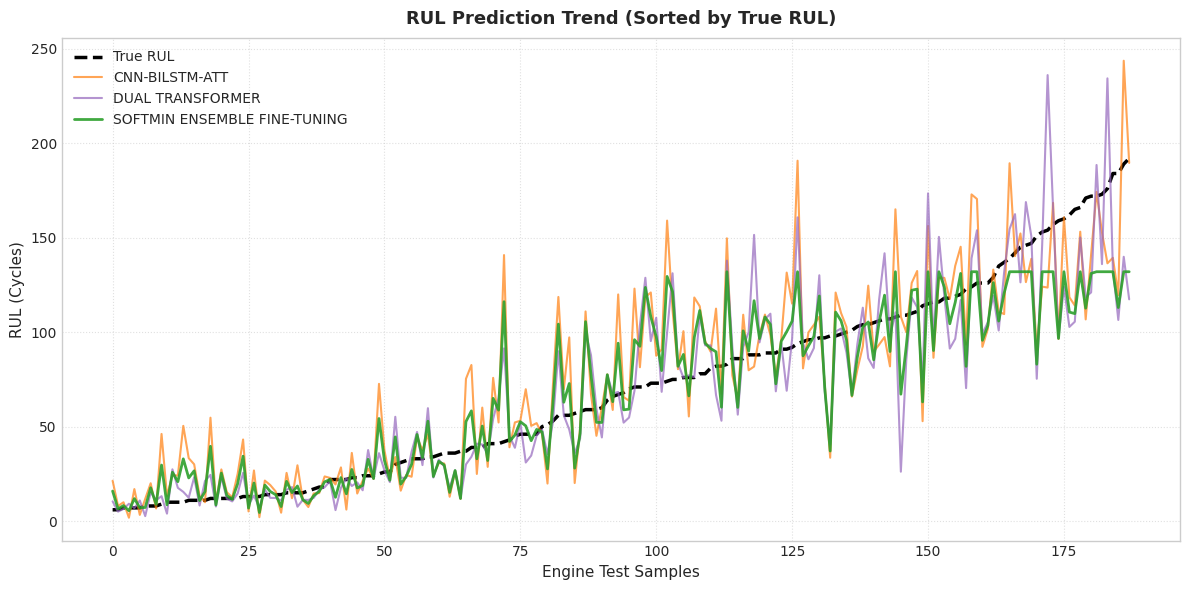

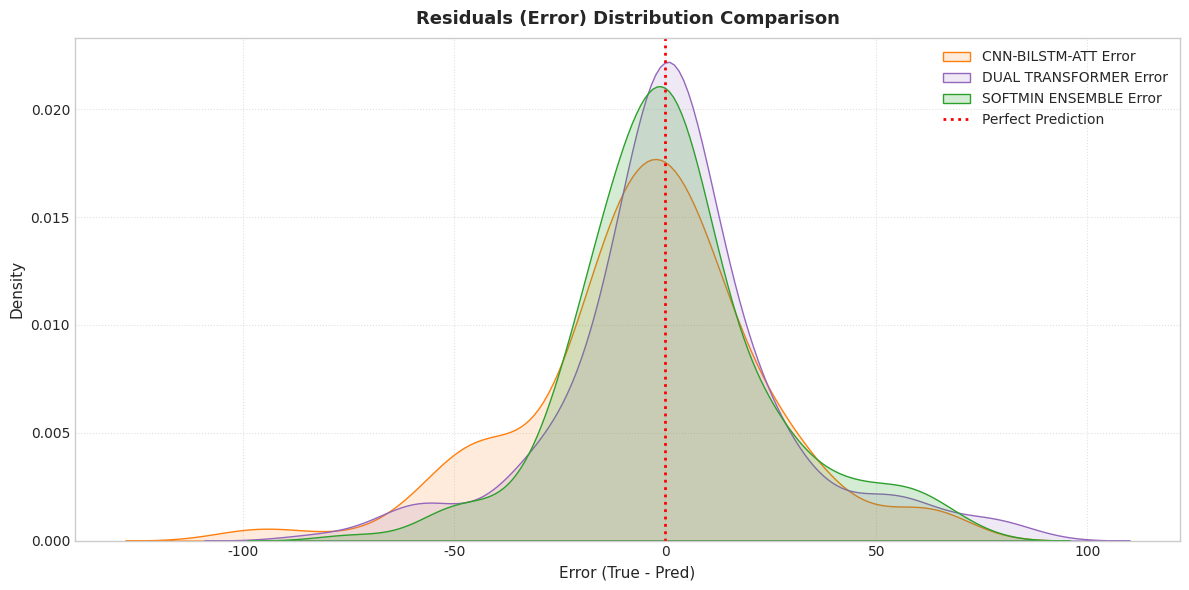

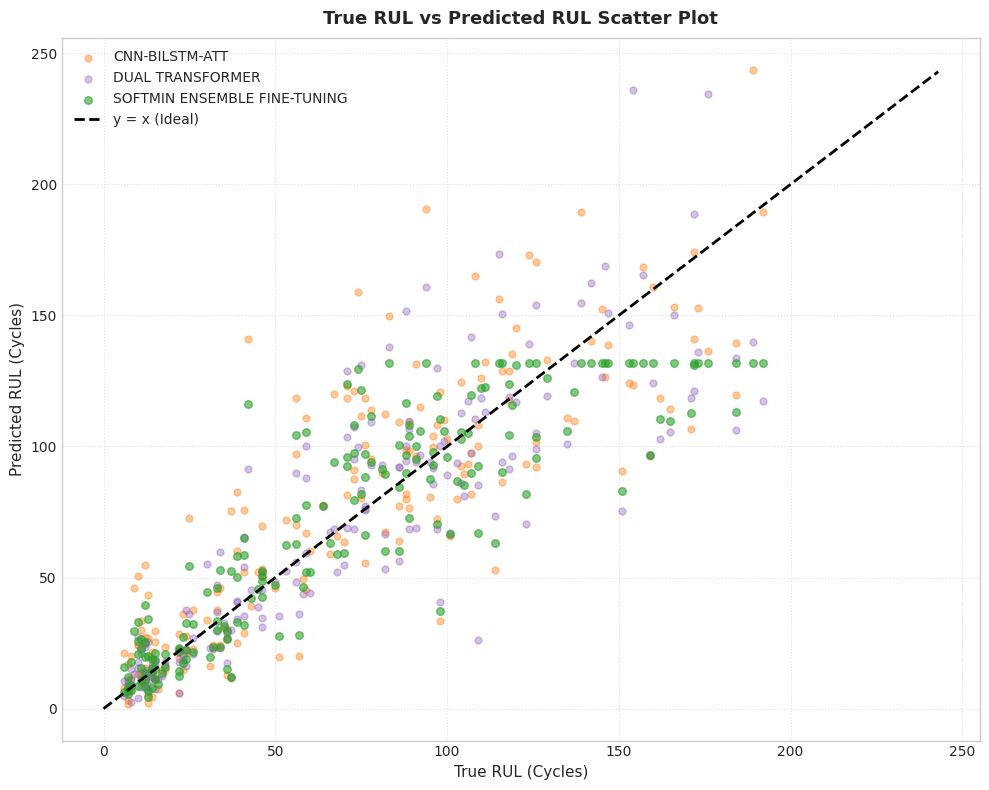

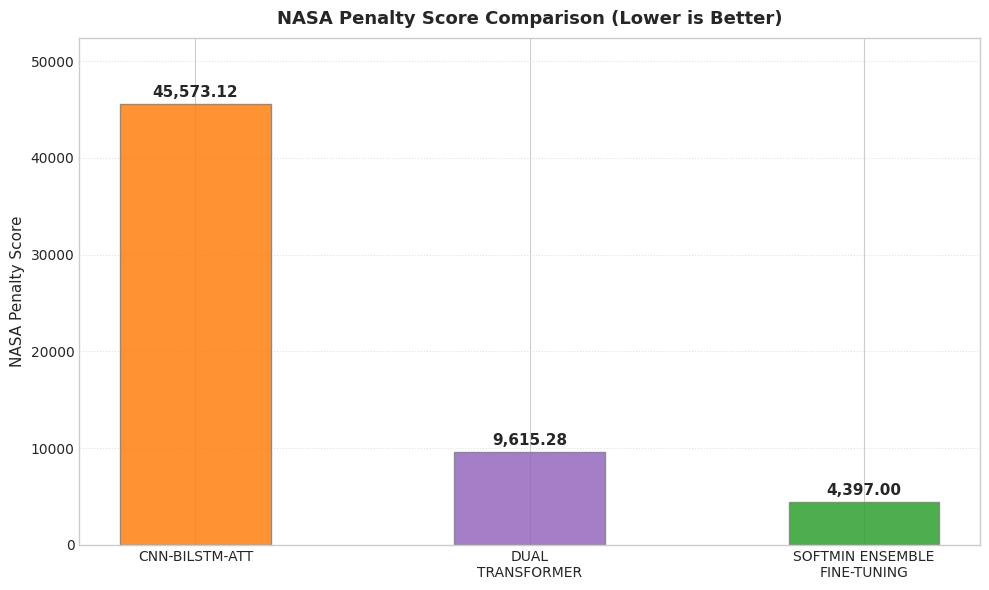

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 🚀 [TypeError 방지] FD004 Softmin 모델 로드에 필수적인 커스텀 레이어 정의
@tf.keras.utils.register_keras_serializable()
class SoftMinBlendCombination(layers.Layer):
    def __init__(self, **kwargs):
        super(SoftMinBlendCombination, self).__init__(**kwargs)
    def call(self, inputs):
        pred_lstm, pred_trans = inputs
        return (pred_lstm + pred_trans) / 2.0
    def get_config(self):
        return super(SoftMinBlendCombination, self).get_config()

# [정의 추가] NameError 해결을 위한 NASA 패널티 스코어 함수
def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    penalty = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return np.sum(penalty)

# --- 모델 로드 및 예측 파트 (SoftMin 레이어 및 신규 경로 반영) ---
custom_objects = {
    'Attention': Attention, 
    'WeightedGeometricMeanCombination': WeightedGeometricMeanCombination,
    'MaxRULClipping': MaxRULClipping,
    'SoftMinBlendCombination': SoftMinBlendCombination # 🚀 객체 등록 완료
}

model_lstm = models.load_model("/Users/gyuminkang/Desktop/nasa/FD004/best_model.keras", custom_objects=custom_objects)
model_trans = models.load_model("/Users/gyuminkang/Desktop/nasa/FD004/best_transformer_model_small.keras", custom_objects=custom_objects)
model_ens = models.load_model("/Users/gyuminkang/Desktop/nasa/FD004/final_softmin_ensemble.keras", custom_objects=custom_objects) # 🚀 경로 변경 완료

pred_lstm = model_lstm.predict(X_test_real).flatten()
pred_trans = model_trans.predict(X_test_real).flatten()
pred_ensemble = model_ens.predict(X_test_real).flatten()

# --- [시각화 시작] 폰트 및 스타일 전역 설정 ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 정확한 색상 테마 정의 (주황, 보라, 초록)
c_lstm = '#ff7f0e'      # Orange
c_trans = '#9467bd'     # Purple
c_ensemble = '#2ca02c'  # Green (Softmin 앙상블에 매핑)
c_true = 'black'        # Black for True RUL

# 오차 데이터 계산 (True - Pred)
err_lstm = y_test_real - pred_lstm
err_trans = y_test_real - pred_trans
err_ensemble = y_test_real - pred_ensemble

# NASA 스코어 계산
nasa_lstm = calculate_nasa_score(y_test_real, pred_lstm)
nasa_trans = calculate_nasa_score(y_test_real, pred_trans)
nasa_ensemble = calculate_nasa_score(y_test_real, pred_ensemble)

# 데이터 정렬 인덱스
sort_idx = np.argsort(y_test_real)

# ======================================================================
# 3. RUL Prediction Trend (Sorted by True RUL) - 개별 창 1
# ======================================================================
plt.figure(figsize=(12, 6)) # 개별 출력 창 크기 설정

plt.plot(y_test_real[sort_idx], label='True RUL', color=c_true, linewidth=2.5, linestyle='--')
plt.plot(pred_lstm[sort_idx], label='CNN-BILSTM-ATT', color=c_lstm, linewidth=1.5, alpha=0.7)
plt.plot(pred_trans[sort_idx], label='DUAL TRANSFORMER', color=c_trans, linewidth=1.5, alpha=0.7)
plt.plot(pred_ensemble[sort_idx], label='SOFTMIN ENSEMBLE FINE-TUNING', color=c_ensemble, linewidth=2.0, alpha=0.9)

plt.title('RUL Prediction Trend (Sorted by True RUL)', fontsize=13, weight='bold', pad=10)
plt.xlabel('Engine Test Samples', fontsize=11)
plt.ylabel('RUL (Cycles)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show() # 첫 번째 창 출력 (창을 닫으면 다음 그래프가 뜹니다)

# ======================================================================
# 4. Residuals (Error) Distribution Comparison - 개별 창 2
# ======================================================================
plt.figure(figsize=(12, 6))

sns.kdeplot(err_lstm, fill=True, color=c_lstm, alpha=0.15, label='CNN-BILSTM-ATT Error')
sns.kdeplot(err_trans, fill=True, color=c_trans, alpha=0.15, label='DUAL TRANSFORMER Error')
sns.kdeplot(err_ensemble, fill=True, color=c_ensemble, alpha=0.2, label='SOFTMIN ENSEMBLE Error')

plt.axvline(0, color='red', linestyle=':', linewidth=2, label='Perfect Prediction')
plt.title('Residuals (Error) Distribution Comparison', fontsize=13, weight='bold', pad=10)
plt.xlabel('Error (True - Pred)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show() # 두 번째 창 출력

# ======================================================================
# 5. True RUL vs Predicted RUL Scatter Plot - 개별 창 3
# ======================================================================
plt.figure(figsize=(10, 8))

plt.scatter(y_test_real, pred_lstm, color=c_lstm, alpha=0.4, s=25, label='CNN-BILSTM-ATT')
plt.scatter(y_test_real, pred_trans, color=c_trans, alpha=0.4, s=25, label='DUAL TRANSFORMER')
plt.scatter(y_test_real, pred_ensemble, color=c_ensemble, alpha=0.6, s=30, label='SOFTMIN ENSEMBLE FINE-TUNING')

# Ideal Line (y = x)
max_val = int(max(y_test_real.max(), pred_lstm.max(), pred_trans.max(), pred_ensemble.max()))
plt.plot([0, max_val], [0, max_val], color=c_true, linestyle='--', linewidth=2, label='y = x (Ideal)')

plt.title('True RUL vs Predicted RUL Scatter Plot', fontsize=13, weight='bold', pad=10)
plt.xlabel('True RUL (Cycles)', fontsize=11)
plt.ylabel('Predicted RUL (Cycles)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show() # 세 번째 창 출력

# ======================================================================
# 6. NASA Penalty Score Comparison (Lower is Better) - 개별 창 4
# ======================================================================
plt.figure(figsize=(10, 6))

models_labels = ['CNN-BILSTM-ATT', 'DUAL\nTRANSFORMER', 'SOFTMIN ENSEMBLE\nFINE-TUNING']
nasa_scores = [nasa_lstm, nasa_trans, nasa_ensemble]
bar_colors = [c_lstm, c_trans, c_ensemble]

bars = plt.bar(models_labels, nasa_scores, color=bar_colors, width=0.45, edgecolor='grey', alpha=0.85)

# 바 상단에 스코어 수치 텍스트 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + max(nasa_scores)*0.01,
             f'{height:,.2f}', ha='center', va='bottom', fontsize=11, weight='bold')

plt.title('NASA Penalty Score Comparison (Lower is Better)', fontsize=13, weight='bold', pad=10)
plt.ylabel('NASA Penalty Score', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.ylim(0, max(nasa_scores) * 1.15)
plt.tight_layout()
plt.show() # 네 번째 창 출력